In [18]:
import os
import random
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as eff_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, BatchNormalization, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random
from pathlib import Path
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import albumentations as A  
from PIL import Image
import warnings 
warnings.filterwarnings('ignore')
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate,
                                     BatchNormalization, Dropout, Dense)
from tensorflow.keras.applications import EfficientNetB0
# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# GPU setup (must come immediately after TF import, before any TF ops)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("GPU config must be set before GPUs are initialized:", e)

In [3]:
# STEP 1 — Constants & dataset layout
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_RADIO_FEATURES = 16

DATA_PATH = Path('/kaggle/input/brain-tumor-mri-dataset')
TRAIN_DIR = DATA_PATH / "Training"
TEST_DIR  = DATA_PATH / "Testing"

LABELS = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(LABELS)
CLASS2IDX = {c:i for i,c in enumerate(LABELS)}

print(f"Training data directory: {TRAIN_DIR}")
print(f"Testing  data directory: {TEST_DIR}")
print("Classes:", LABELS)


Training data directory: /kaggle/input/brain-tumor-mri-dataset/Training
Testing  data directory: /kaggle/input/brain-tumor-mri-dataset/Testing
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
# STEP 2 — List file paths and build labels
# (Use paths to avoid mixing arrays+paths later)
def list_paths_and_labels(root: Path, class_names):
    paths, labels = [], []
    for cls in class_names:
        cls_paths = sorted([str(p) for p in (root/cls).glob("*") if p.is_file()])
        paths.extend(cls_paths)
        labels.extend([CLASS2IDX[cls]]*len(cls_paths))
    return np.array(paths), np.array(labels, dtype=np.int32)

train_paths, train_labels = list_paths_and_labels(TRAIN_DIR, LABELS)
test_paths,  test_labels  = list_paths_and_labels(TEST_DIR,  LABELS)

print("Train files:", len(train_paths))
print("Test  files:", len(test_paths))


Train files: 5712
Test  files: 1311


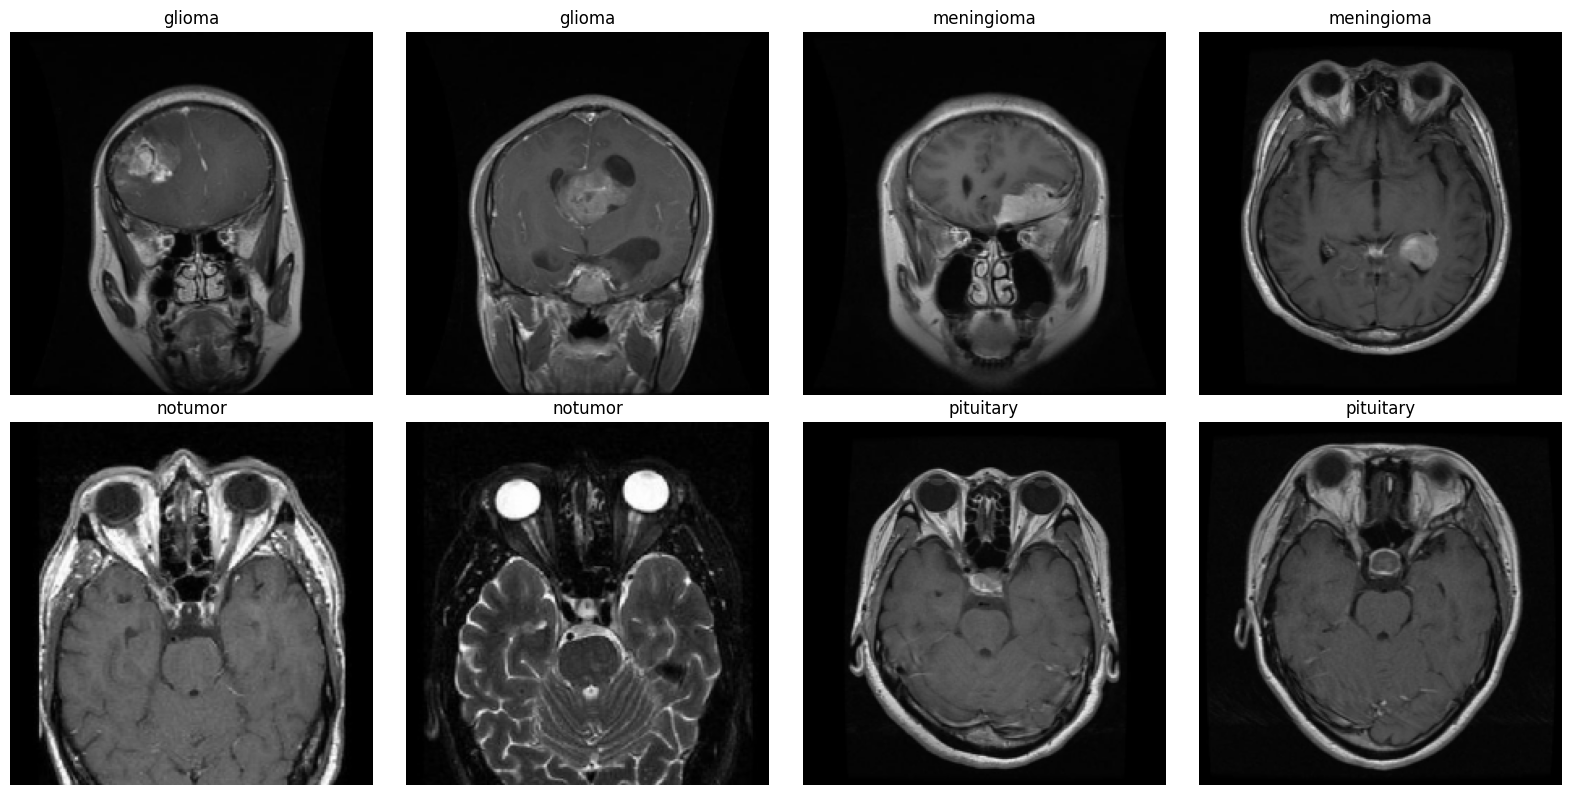

In [6]:
# Show 2 sample images per class (8 images total) in 2 rows x 4 cols
samples_per_class = 2
ncols = 4
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 8))

# flatten axes for easy indexing
axes = axes.flatten()

# Use autocrop_square_cv2 if it's already defined; otherwise use a small fallback
_autocrop = globals().get("autocrop_square_cv2", None)
def _safe_autocrop(img_rgb):
    if _autocrop is not None:
        try:
            return _autocrop(img_rgb)
        except Exception:
            pass
    # fallback: center-crop to square then resize
    h, w = img_rgb.shape[:2]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    crop = img_rgb[y0:y0+s, x0:x0+s]
    return cv2.resize(crop, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

idx = 0
for cls_idx, cls_name in enumerate(LABELS):
    cls_paths = train_paths[train_labels == cls_idx]
    if len(cls_paths) == 0:
        continue
    selected = cls_paths[:samples_per_class]
    for p in selected:
        if idx >= nrows * ncols:
            break
        img_bgr = cv2.imread(p)
        if img_bgr is None:
            # placeholder if file can't be read
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        else:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img = _safe_autocrop(img_rgb)
        axes[idx].imshow(img)
        axes[idx].set_title(cls_name)
        axes[idx].axis("off")
        idx += 1

# fill remaining slots (if any) with empty axes
for i in range(idx, nrows * ncols):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

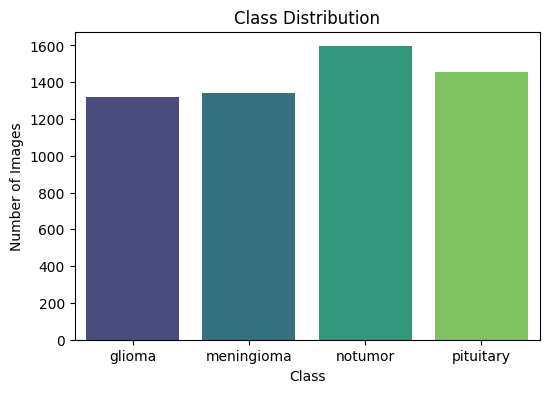

In [12]:
counts = np.bincount(train_labels, minlength=NUM_CLASSES)
train_counts = dict(zip(LABELS, counts.tolist()))

plt.figure(figsize=(6, 4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [13]:
# STEP 3 — Class weights (handle imbalance)
counts = np.bincount(train_labels, minlength=NUM_CLASSES)
total = counts.sum()
class_weights = {i: float(total / (NUM_CLASSES * max(counts[i], 1))) for i in range(NUM_CLASSES)}
print("Class counts:", counts.tolist())
print("Class weights:", class_weights)


Class counts: [1321, 1339, 1595, 1457]
Class weights: {0: 1.080999242997729, 1: 1.0664675130694548, 2: 0.8952978056426333, 3: 0.9800960878517502}


In [19]:
# STEP 4 — Radio features lookup (replace with real features if you have them)
Create a per-file deterministic vector to keep shapes consistent.
rng = np.random.default_rng(SEED)
all_paths = np.concatenate([train_paths, test_paths])
# Deterministic per-path "random" vectors via hashing indices
path_to_id = {p:i for i,p in enumerate(all_paths)}
radio_matrix = rng.standard_normal((len(all_paths), NUM_RADIO_FEATURES)).astype("float32")

# Build a TF lookup table: path(string) -> int id
keys_t = tf.constant(list(path_to_id.keys()), dtype=tf.string)
vals_t = tf.constant(list(path_to_id.values()), dtype=tf.int64)
id_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys_t, vals_t), default_value=-1
)


SyntaxError: invalid syntax (2395585703.py, line 2)

In [20]:
# STEP 5 — Preprocessing utils (autocrop + EfficientNet preprocess)
def autocrop_square_cv2(img_rgb_uint8):
    g = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
    m = g > 5
    if m.sum() < 50:
        return cv2.resize(img_rgb_uint8, (IMAGE_SIZE, IMAGE_SIZE))
    ys, xs = np.where(m)
    y1, y2, x1, x2 = ys.min(), ys.max(), xs.min(), xs.max()
    pad = 8
    y1, x1 = max(y1 - pad, 0), max(x1 - pad, 0)
    y2, x2 = min(y2 + pad, img_rgb_uint8.shape[0]-1), min(x2 + pad, img_rgb_uint8.shape[1]-1)
    crop = img_rgb_uint8[y1:y2+1, x1:x2+1]
    h, w = crop.shape[:2]
    if h != w:
        s = max(h, w)
        canvas = np.zeros((s, s, 3), dtype=crop.dtype)
        yoff, xoff = (s - h)//2, (s - w)//2
        canvas[yoff:yoff+h, xoff:xoff+w] = crop
        crop = canvas
    return cv2.resize(crop, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

def eff_preprocess_tf(x):
    return tf.keras.applications.efficientnet.preprocess_input(x)


In [21]:
# STEP 6 — tf.data mapping fns (paths -> (image, radio), label)
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
], name="augmenter")

def decode_and_autocrop(path):
    # path: tf.string -> image uint8 [H,W,3]
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)  # uint8
    img = tf.cast(img, tf.uint8)

    # Run OpenCV autocrop via numpy_function (keeps everything on CPU here)
    img = tf.numpy_function(lambda x: autocrop_square_cv2(x), [img], tf.uint8)
    img.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])  # static shape for later layers
    img = tf.cast(img, tf.float32)
    return img

def path_to_example(path, label, training=False):
    # 1) load & autocrop
    img = decode_and_autocrop(path)

    # 2) EfficientNet preprocess (expects float32)
    img = eff_preprocess_tf(img)

    # 3) optional augmentation (only on training)
    if training:
        img = augmenter(img, training=True)

    # 4) radio features via lookup
    idx = id_table.lookup(path)                      # int64
    radio = tf.gather(radio_matrix, tf.cast(idx, tf.int32))  # (NUM_RADIO_FEATURES,)

    # 5) one-hot label
    y = tf.one_hot(label, depth=NUM_CLASSES, dtype=tf.float32)

    # Named inputs match model inputs
    return {"image_input": img, "radio_input": radio}, y

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p,l: path_to_example(p,l,training=training),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [22]:
# STEP 7 — Train/Val split FROM TRAIN FOLDER (keep Testing fully for test)
# Make a stratified split index
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
(train_idx, val_idx) = next(sss.split(train_paths, train_labels))

tr_paths, tr_labels = train_paths[train_idx], train_labels[train_idx]
va_paths, va_labels = train_paths[val_idx],  train_labels[val_idx]

train_ds = make_dataset(tr_paths, tr_labels, training=True)
val_ds   = make_dataset(va_paths, va_labels, training=False)
test_ds  = make_dataset(test_paths, test_labels, training=False)

print("Batches — train:", len(list(train_ds)), "val:", len(list(val_ds)), "test:", len(list(test_ds)))


NameError: name 'SEED' is not defined

In [23]:
# STEP 8 — SAME HYBRID MODEL (CNN + radio -> concat -> dense -> softmax)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D, GlobalMaxPooling2D,
                                     Concatenate, BatchNormalization, Dropout, Dense)
from tensorflow.keras.models import Model

# Inputs
cnn_input   = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="image_input")
radio_input = Input(shape=(NUM_RADIO_FEATURES,),      name="radio_input")

# EfficientNet backbone (no built-in aug here; aug is in dataset)
base = EfficientNetB0(weights="imagenet", include_top=False, input_tensor=cnn_input)
base.trainable = False  # Phase 1

# CNN feature head
h   = base.output
gap = GlobalAveragePooling2D()(h)
gmp = GlobalMaxPooling2D()(h)
cnn_feat = Concatenate(name="cnn_gap_gmp")([gap, gmp])
cnn_feat = BatchNormalization()(cnn_feat)
cnn_feat = Dropout(0.5)(cnn_feat)

# Radio branch
radio_feat = Dense(64, activation="relu")(radio_input)
radio_feat = BatchNormalization()(radio_feat)
radio_feat = Dropout(0.3)(radio_feat)

# Merge branches
merged = Concatenate(name="merge_cnn_radio")([cnn_feat, radio_feat])
merged = Dense(128, activation="relu")(merged)
merged = BatchNormalization()(merged)
merged = Dropout(0.4)(merged)

# Multi-class output
out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(merged)

model = Model(inputs={"image_input": cnn_input, "radio_input": radio_input}, outputs=out)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,398,183 (16.78 MB)

 Trainable params: 343,108 (1.31 MB)

 Non-trainable params: 4,055,075 (15.47 MB)

In [39]:
# STEP 9 — Train (Phase 1: frozen backbone)
cbs = [
    tf.keras.callbacks.ModelCheckpoint("HybridModel_best.keras", monitor="val_loss",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=2, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                     restore_best_weights=True, verbose=1),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)


Epoch 1/15


I0000 00:00:1760263471.123933     107 service.cc:148] XLA service 0x7e6ae00538b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760263471.125920     107 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760263473.969949     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.3468 - loss: 2.2113   

I0000 00:00:1760263483.988893     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6698 - loss: 1.0430
Epoch 1: val_loss improved from inf to 0.47488, saving model to HybridModel_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 86s 391ms/step - accuracy: 0.6703 - loss: 1.0411 - val_accuracy: 0.8206 - val_loss: 0.4749 - learning_rate: 0.0010
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7993 - loss: 0.5530
Epoch 2: val_loss improved from 0.47488 to 0.44361, saving model to HybridModel_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 249ms/step - accuracy: 0.7994 - loss: 0.5529 - val_accuracy: 0.8390 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8306 - loss: 0.4829
Epoch 3: val_loss improved from 0.44361 to 0.42379, saving model to HybridModel_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 248ms/step - accuracy: 0.8306 - loss: 0.4826 - val_accuracy: 0.8355 - val_loss: 0.4238 - learning_rate: 0.0010
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 222

In [40]:
# STEP 10 — Fine-tune (Phase 2: unfreeze backbone)
for layer in base.layers:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)


Epoch 1/10


E0000 00:00:1760264118.316022     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264118.503526     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264118.969403     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264119.175449     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264119.533133     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.6386 - loss: 1.0022

E0000 00:00:1760264189.750853     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264189.939469     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264190.395252     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264190.603630     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760264190.961976     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.6390 - loss: 1.0013
Epoch 1: val_loss did not improve from 0.27412
143/143 ━━━━━━━━━━━━━━━━━━━━ 174s 590ms/step - accuracy: 0.6393 - loss: 1.0005 - val_accuracy: 0.8539 - val_loss: 0.4034 - learning_rate: 1.0000e-05
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7691 - loss: 0.6674
Epoch 2: val_loss did not improve from 0.27412
143/143 ━━━━━━━━━━━━━━━━━━━━ 44s 310ms/step - accuracy: 0.7692 - loss: 0.6671 - val_accuracy: 0.8486 - val_loss: 0.4128 - learning_rate: 1.0000e-05
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8031 - loss: 0.5374
Epoch 3: val_loss did not improve from 0.27412

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
143/143 ━━━━━━━━━━━━━━━━━━━━ 45s 313ms/step - accuracy: 0.8032 - loss: 0.5372 - val_accuracy: 0.8425 - val_loss: 0.4079 - learning_rate: 1.0000e-05
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8341 - loss: 0.4

              precision    recall  f1-score   support

      glioma      0.859     0.810     0.834       300
  meningioma      0.800     0.641     0.711       306
     notumor      0.945     0.933     0.939       405
   pituitary      0.760     0.970     0.852       300

    accuracy                          0.845      1311
   macro avg      0.841     0.838     0.834      1311
weighted avg      0.849     0.845     0.842      1311



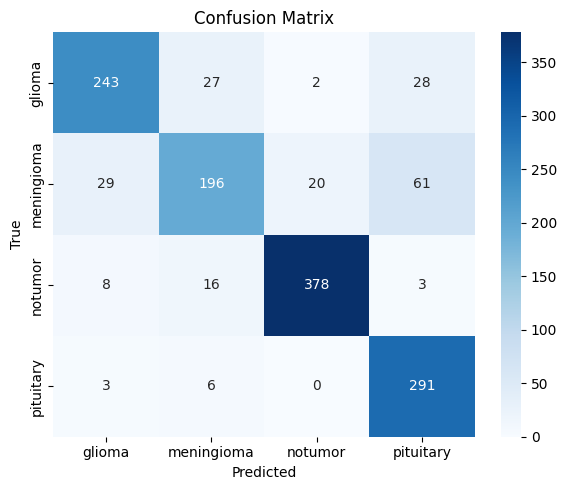

In [41]:
# STEP 11 — Evaluation & Confusion Matrix
# Collect true/pred labels from test_ds
y_true_all, y_pred_all = [], []
for batch in test_ds:
    x_batch, y_batch = batch
    probs = model.predict(x_batch, verbose=0)
    y_pred_all.append(np.argmax(probs, axis=1))
    y_true_all.append(np.argmax(y_batch.numpy(), axis=1))

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print(classification_report(y_true_all, y_pred_all, target_names=LABELS, digits=3))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

gc.collect(); tf.keras.backend.clear_session()
